## 1.Import Necessory Libraries

In [89]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

## 2.Import Dataset

In [90]:
claimants_data = pd.read_csv("claimants.csv.csv")
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3.Data Understanding

In [91]:
claimants_data.shape

(1340, 7)

In [92]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [93]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4.Data Preparation

### 4.1 Data Cleaning

In [94]:
claimants_data.dropna(inplace= True)
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [95]:
1340-1096

244

In [96]:
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

### 4.2 Seperate your inputs and outputs

In [97]:
X= claimants_data.drop(labels = ["CASENUM","ATTORNEY"],axis =1)
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [98]:
y = claimants_data["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5.Model Building

In [203]:
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=20,shuffle=True,random_state=34)

In [204]:
x_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
716,1.0,1.0,0.0,30.0,1.105
719,1.0,1.0,0.0,33.0,0.781
58,1.0,1.0,0.0,44.0,0.139
377,1.0,1.0,0.0,37.0,4.860
796,1.0,1.0,0.0,9.0,3.386
...,...,...,...,...,...
731,0.0,1.0,0.0,30.0,4.014
817,0.0,1.0,0.0,48.0,0.390
557,0.0,1.0,0.0,30.0,0.565
386,1.0,1.0,0.0,35.0,0.860


In [205]:
x_test

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
627,1.0,1.0,0.0,40.0,6.337
1125,1.0,1.0,0.0,37.0,4.609
1124,1.0,1.0,0.0,46.0,0.730
1025,1.0,1.0,0.0,38.0,3.406
481,1.0,1.0,0.0,70.0,0.566
1033,1.0,1.0,0.0,8.0,0.590
571,1.0,1.0,0.0,44.0,3.313
830,1.0,1.0,0.0,34.0,6.057
704,1.0,1.0,0.0,10.0,7.079
734,1.0,1.0,0.0,17.0,0.069


In [206]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

## 6.Model Training

In [207]:
dt_model = DecisionTreeClassifier(criterion="entropy",max_depth=5)

### Grid Search CV (Cross Validation)

In [208]:
from sklearn.model_selection import GridSearchCV

In [209]:
grid_search = GridSearchCV(estimator = dt_model,param_grid = {"max_depth":[5,6,7,8,9,10],
                                                              "criterion":["gini","entropy"]})

grid_search.fit(X,y)

print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'entropy', 'max_depth': 5}
0.7235284350352844


In [210]:
grid_search = GridSearchCV(estimator = dt_model,param_grid = {"max_depth":[5,6,7,8,9,10],
                                                              "criterion":["gini","entropy"]})

grid_search.fit(x_train,y_train)#this is take a currect fit for a data

print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'entropy', 'max_depth': 5}
0.7332644272179156


In [211]:
dt_model.fit(x_train,y_train)#this base is fit a data

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


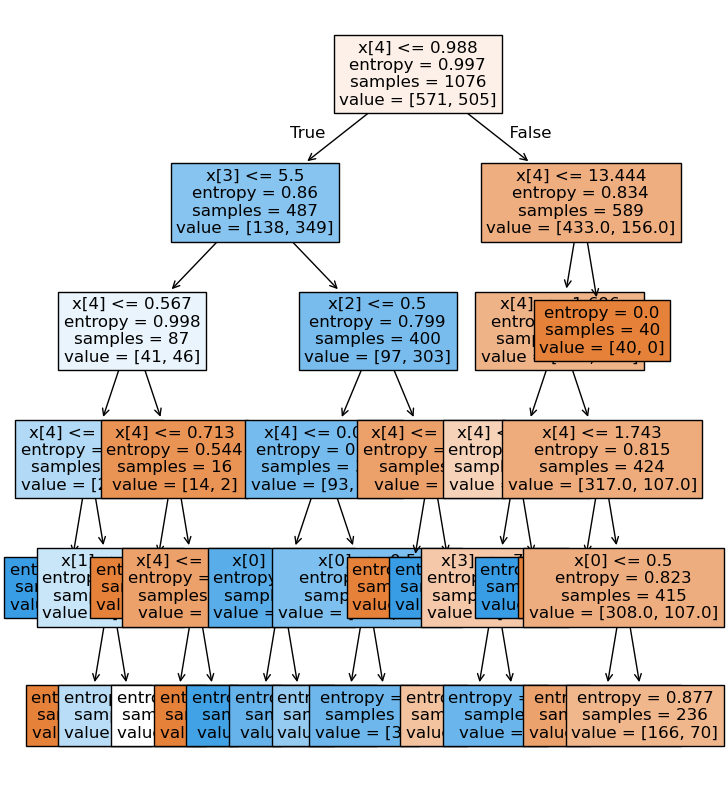

In [212]:
plt.figure(figsize = (8,10))
plot_tree(decision_tree = dt_model,fontsize=12,filled=True)
plt.show()

## 7.Model Testing

### Training Data

In [213]:
y_pred_train = dt_model.predict(x_train)
y_pred_train

array([0, 1, 1, ..., 1, 1, 0], shape=(1076,))

### Testing Data

In [214]:
y_pred_test = dt_model.predict(x_test)
y_pred_test

array([0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1])

In [215]:
# claimants_data["Predicted_Output"] = logistic_model.predict(X)
# claimants_data

## 8.Model Evaluation

In [216]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve

### Training Data's Evaluation Metrics

In [217]:
print(confusion_matrix(y_train,y_pred_train))

[[453 118]
 [148 357]]


In [218]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.75      0.79      0.77       571
           1       0.75      0.71      0.73       505

    accuracy                           0.75      1076
   macro avg       0.75      0.75      0.75      1076
weighted avg       0.75      0.75      0.75      1076



In [219]:
accuracy_score(y_train,y_pred_train)

0.7527881040892194

### ROC Curve - Receiver Operating Characteristics

#### AUC - Area Under this Curve

0.7501378509129372


Text(0, 0.5, 'True Positive Rate')

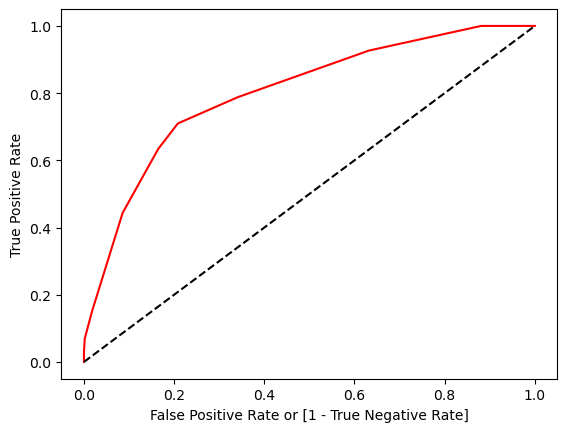

In [220]:
fpr, tpr, thresholds = roc_curve(y_train, dt_model.predict_proba (x_train)[:,1])

auc = roc_auc_score(y_train,y_pred_train)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

### Test Data's Evaluation Metrics

In [221]:
print(confusion_matrix(y_test,y_pred_test))

[[6 1]
 [5 8]]


In [222]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.55      0.86      0.67         7
           1       0.89      0.62      0.73        13

    accuracy                           0.70        20
   macro avg       0.72      0.74      0.70        20
weighted avg       0.77      0.70      0.71        20



In [223]:
accuracy_score(y_test,y_pred_test)

0.7

0.7362637362637363


Text(0, 0.5, 'True Positive Rate')

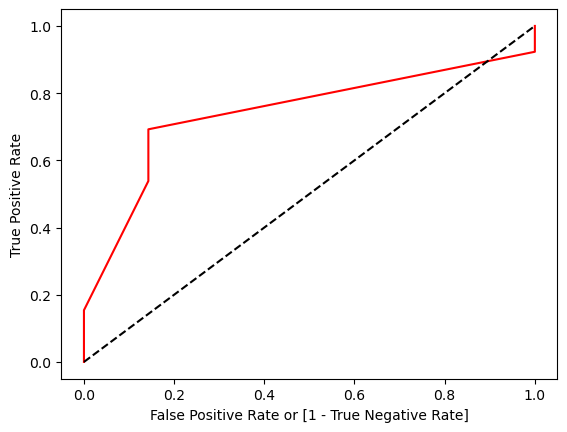

In [224]:
fpr, tpr, thresholds = roc_curve(y_test, dt_model.predict_proba (x_test)[:,1])

auc = roc_auc_score(y_test,y_pred_test)
print(auc)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color='red', label='logit model ( area  = %0.2f)'%auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

## BIAS - VARIANCE

* Training Error/Accuracy - Bias
* Test Error/Accuracy - Variance.

### Model Overfitting - Less Bias and High Variance.
### Model Underfitting - High Bias and Less Variance.

### EXPECTED MODEL -- GENERALIZED MODEL - Less Bias and Less Variance.

So, there is always a **Tradeoff maintaned between Bias and Variance.**

## 9.Model Deployment

In [31]:
from pickle import dump

In [32]:
dump(logistic_model,open("claimants.pkl","wb"))

# THE END !!!